In [ ]:
# Author: Cameron Liu 
# Purpose: To graph all the information from the simulations 

import matplotlib.pyplot as plt
import numpy as np
import statistics      
from scipy import stats

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
all_datasets = [] # stores all the datasets
timesteps = [] # timesteps, 0 to 20,000
#hmean_subtracted_data = []; subtractsed_harmonic_means = []; harmonic_means = []
# subtracted_arithmetic_means = []; subtracted_geometric_means = []; selective_deaths = []
# arithmetic_means = []; geometric_means = []

def parse_files(file_sd, sd, burnin):
    # Purpose: Parses the files by building strings in order to gather all the data from the file
    # 
    # Returns: A list of tuples. (A, B). Let A be the UD associated with the file, and B be the Data from the file. 

    for ud in uds: 
        filename = "/Users/cameronliu/Desktop/Research/sd-" + str(sd) + "/datafor_relative_tskitstatus_O" + str(burnin) + "_fixationcalc_OFF_Sb_1.0000_deldist_point_bendist_exponential_mub_0.0000_chromnum_23_N0_2000_mud_" + str(ud) + "_L_200_seed_24_Sd_" + str(file_sd) + "/rawdataforNxtimesteps20000popsize2000mutrate" + str(ud) + "chromsize200chromnum23benmutrate0.0000Sb1.0000.txt"
        file_data = []
        with open(filename, "r") as file:
            next(file) # skips the first line
            for line in file: 
                line = line.strip().split(",")
                if len(timesteps) < 20000: # Skips adding after the 0 - 20,000 timesteps
                    timesteps.append(line[0])
                file_data.append(float(line[3]))
        all_datasets.append((ud, file_data, sd))
    return all_datasets

def sort_csv(location, sort_by):
    sorted = []

    filename = location
    with open(filename, "r") as file: 
        next(file)
        for line in file: 
            line = line.strip().split(",")
            data_type = type(line[2])
            if (data_type(line[2]) == data_type(sort_by)):  
                sorted.append((line[0], line[1]))
    sorted.sort()
    return sorted


def slice_data(dataset):
    timesteps[:] = timesteps[2000:]  # In-place update
    new_dataset = []
    for ud, data, sd in dataset:
        data = data[2000:]
        new_dataset.append([ud, data, sd])
    return new_dataset
    


def calculate_harmonic_means(sd): 
    hmean_subtracted_data = []
    subtracted_harmonic_means = []
    harmonic_means = []
    for info in all_datasets: 
        ud = info[0]; data = info[1]; file_sd = info[2]

        subtracted_data = [1 - value for value in data]
        original_omega = statistics.harmonic_mean(subtracted_data)
        
        new_omega = 1 - statistics.harmonic_mean(data)

        harmonic_mean = statistics.harmonic_mean(data)

        hmean_subtracted_data.append((ud, original_omega, file_sd))
        subtracted_harmonic_means.append((ud, new_omega, file_sd))
        harmonic_means.append((ud, harmonic_mean, file_sd))
    return hmean_subtracted_data, subtracted_harmonic_means, harmonic_means


def calculate_geometric_means(sd):
    subtracted_geometric_means = []
    for (ud, data, file_sd) in all_datasets: 
        if sd == file_sd: 
        # filter out the non-positive values since geometric mean is undefined for them
            positive_data = [x for x in data if x > 0]
            if not positive_data:
                continue  # skip this dataset if all values are zero or negative
            subtracted_mean = 1 - statistics.geometric_mean(positive_data)
            subtracted_geometric_means.append((ud, subtracted_mean, file_sd))
    return subtracted_geometric_means

def calculate_arithmetic_means(sd):
    subtracted_arithmetic_means = []
    for ud, data, file_sd in all_datasets:
        subtracted_arithmetic_mean = 1 - statistics.mean(data)
        subtracted_arithmetic_means.append((ud, subtracted_arithmetic_mean, file_sd))
    return subtracted_arithmetic_means
        

def moving_average(data, window):
    weights = np.ones(window) / window
    return np.convolve(data, weights, mode='valid')

# parse_files()
# slice_data()
# calculate_harmonic_means()
# calculate_arithmetic_means()
# calculate_geometric_means()




: 

In [ ]:
# This cell allows me to be able to get all the information from the parsed files, and be able to edit them all at once rather than editing them individually. 
# This is done by gathering the information beforehand and graphing that information aterwards by iterating through.


# 0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8 are the values of the different UDS that we ran

beginning = 2000; end = 20000

data = all_datasets[0][beginning:end]

for tuple in all_datasets: 
    selective_deaths = tuple[1]

    sliced_timesteps = timesteps[beginning:end]
    selective_deaths = selective_deaths[beginning:end]
    selective_deaths = [y for y in selective_deaths]

    # Smoothes the Data from the file
    window_size = 500 # 
    smoothed_y_data = moving_average(selective_deaths, window_size)
    smoothed_x_data = sliced_timesteps[window_size - 1:]  # Align the x with smoothed Y's


    # plot/figure setup for size, color, data, and axis
    plt.figure(figsize=(15, 7))
    plt.plot(smoothed_x_data, smoothed_y_data, color='blue')
    plt.title("Population Size of 2000, UD = " + str(tuple[0]) )
    plt.xlabel("Timesteps")
    plt.ylabel("Fraction of Selective Deaths")

    plt.xscale('log')
    plt.tight_layout()

    # every step on the X-axis
    step_x = 500
    tick_indices_x = list(range(0, len(timesteps), step_x))

    # every step on the Y-axis
    y_min = 0; y_max = max(tuple[1])
    step_y = 0.02
    tick_values_y = np.arange(y_min, y_max + step_y, step_y)
    plt.yticks(tick_values_y)

    # shows the plot
    plt.tight_layout()
    plt.show()





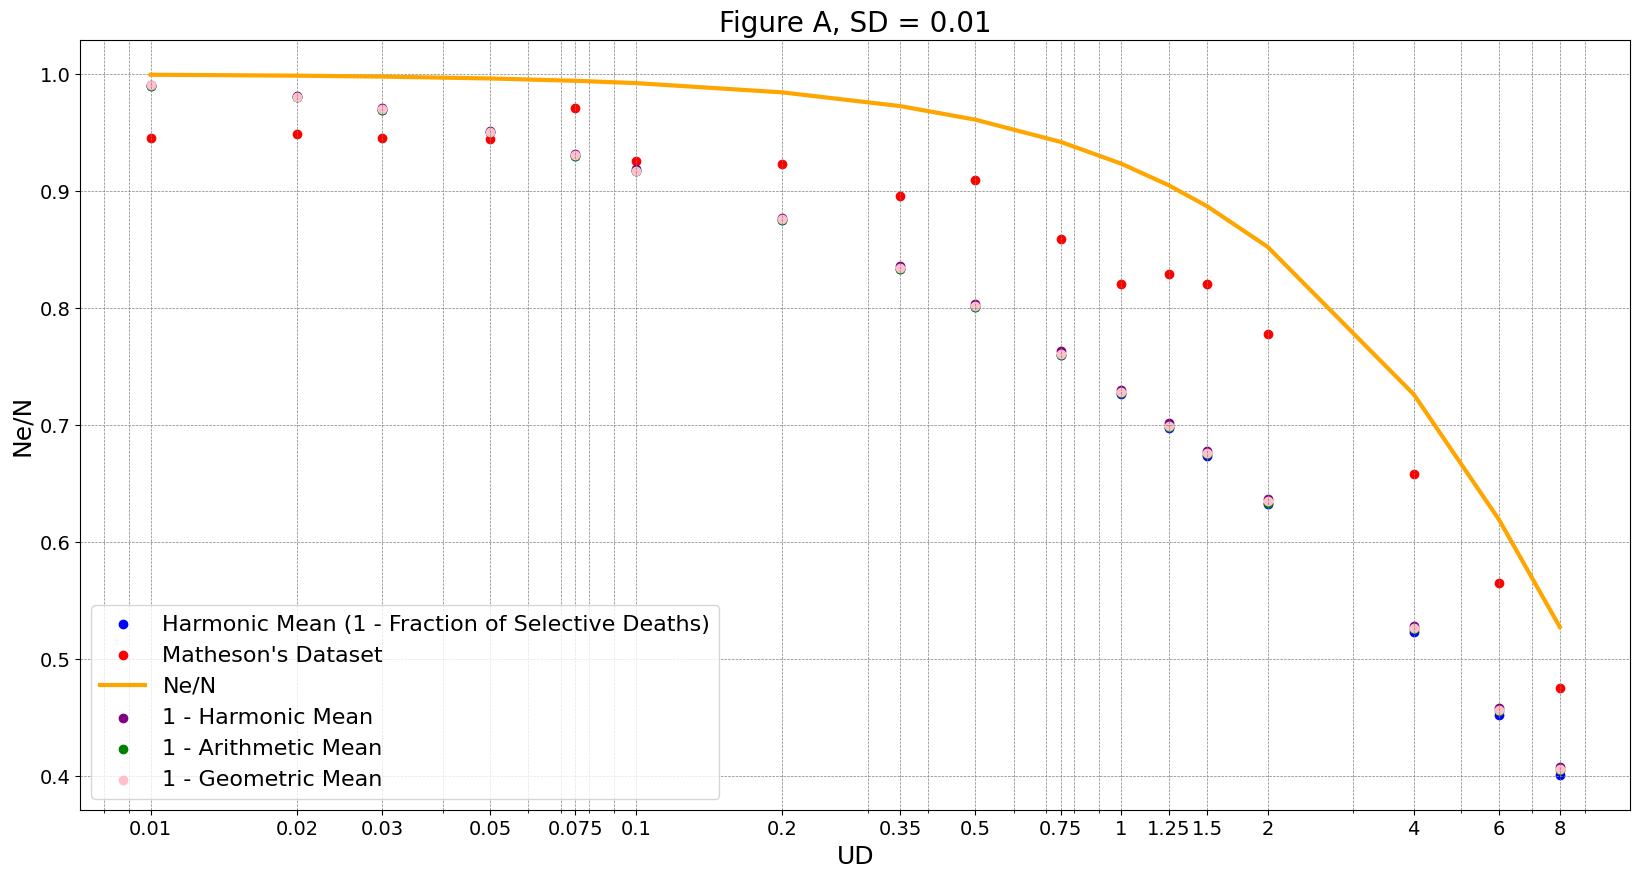

In [19]:
# This cell is dedicated to the comparison graphs of SD = 0.01, 1A.

sd = 0.01

a_data = parse_files("0.010000", sd, "N_BURNIN")
slice_data(a_data)
fig_a_hmean_subtracted_data, fig_a_subtracted_harmonic_means, fig_a_harmonic_means = calculate_harmonic_means(sd)
figa_subtracted_arithmetic_means = calculate_arithmetic_means(sd)
figa_subtracted_geometric_means =calculate_geometric_means(sd)

plt.figure(figsize=(20, 10))


location = "/Users/cameronliu/Desktop/Research/BGSpaperdataforFigure1A.csv"
figA_matheson_dataset = sort_csv(location, 5000)
figA_matheson_dataset = [(float(x), float(y)) for x, y in figA_matheson_dataset]
fig_a_subtracted_harmonic_means.sort()


# Build y-axis values by matching ud in tuples
figA_hmean_subtracted_data = [omega for (ud, omega, sd) in fig_a_hmean_subtracted_data if ud in uds] # The original omega 
figA_matheson_dataset = [omega for (ud, omega) in figA_matheson_dataset if ud in uds] # Matheson's Original (simulation, after finishing, make the genetic tree, then add mutations)
figA_matheson_calculated_data = [] # matheson's calculated omega from the data
for ud in uds: 
    figA_matheson_calculated_data.append(float(np.exp(-8*ud*sd)))
figA_subtracted_hmean = [omega for (ud, omega, sd) in fig_a_subtracted_harmonic_means if ud in uds] # our model, new omega
figA_subtracted_arithmetic_means = [arithmetic for (ud, arithmetic, sd) in figa_subtracted_arithmetic_means if ud in uds]
figA_subtracted_geometric_means = [geometric_mean for (ud, geometric_mean, sd) in figa_subtracted_geometric_means if ud in uds]


plt.scatter(uds, figA_hmean_subtracted_data, color='blue', label='Harmonic Mean (1 - Fraction of Selective Deaths)') # Our Original Omega
plt.scatter(uds, figA_matheson_dataset, color='red', label="Matheson's Dataset") # Matheson's Dataset
plt.plot(uds, figA_matheson_calculated_data, color='orange', label="Ne/N") # Matheson's Calculated Data (using the formula)
plt.scatter(uds, figA_subtracted_hmean, color='purple', label="1 - Harmonic Mean") # Our New Omega 
plt.scatter(uds, figA_subtracted_arithmetic_means, color="green", label="1 - Arithmetic Mean") # 1 - Arithmetic Mean
plt.scatter(uds, figA_subtracted_geometric_means, color="pink", label = "1 - Geometric Mean") # 1 - Geometric 

# Logarithmic scale on x-axis
plt.legend(fontsize='small')
plt.xscale('log')

# Set custom ticks (still linear labels)
ticks = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
plt.xticks(ticks, labels=[str(t) for t in ticks])

# Labels and aesthetics

plt.xlabel("UD")
plt.ylabel("Ne/N")
plt.legend()
plt.title("Figure A, SD = " + str(sd))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig("/Users/cameronliu/Desktop/Research/other-graphs/" + "figAcomparison_graphs.png", dpi=300, bbox_inches='tight')

plt.show()

# unlinked background selection


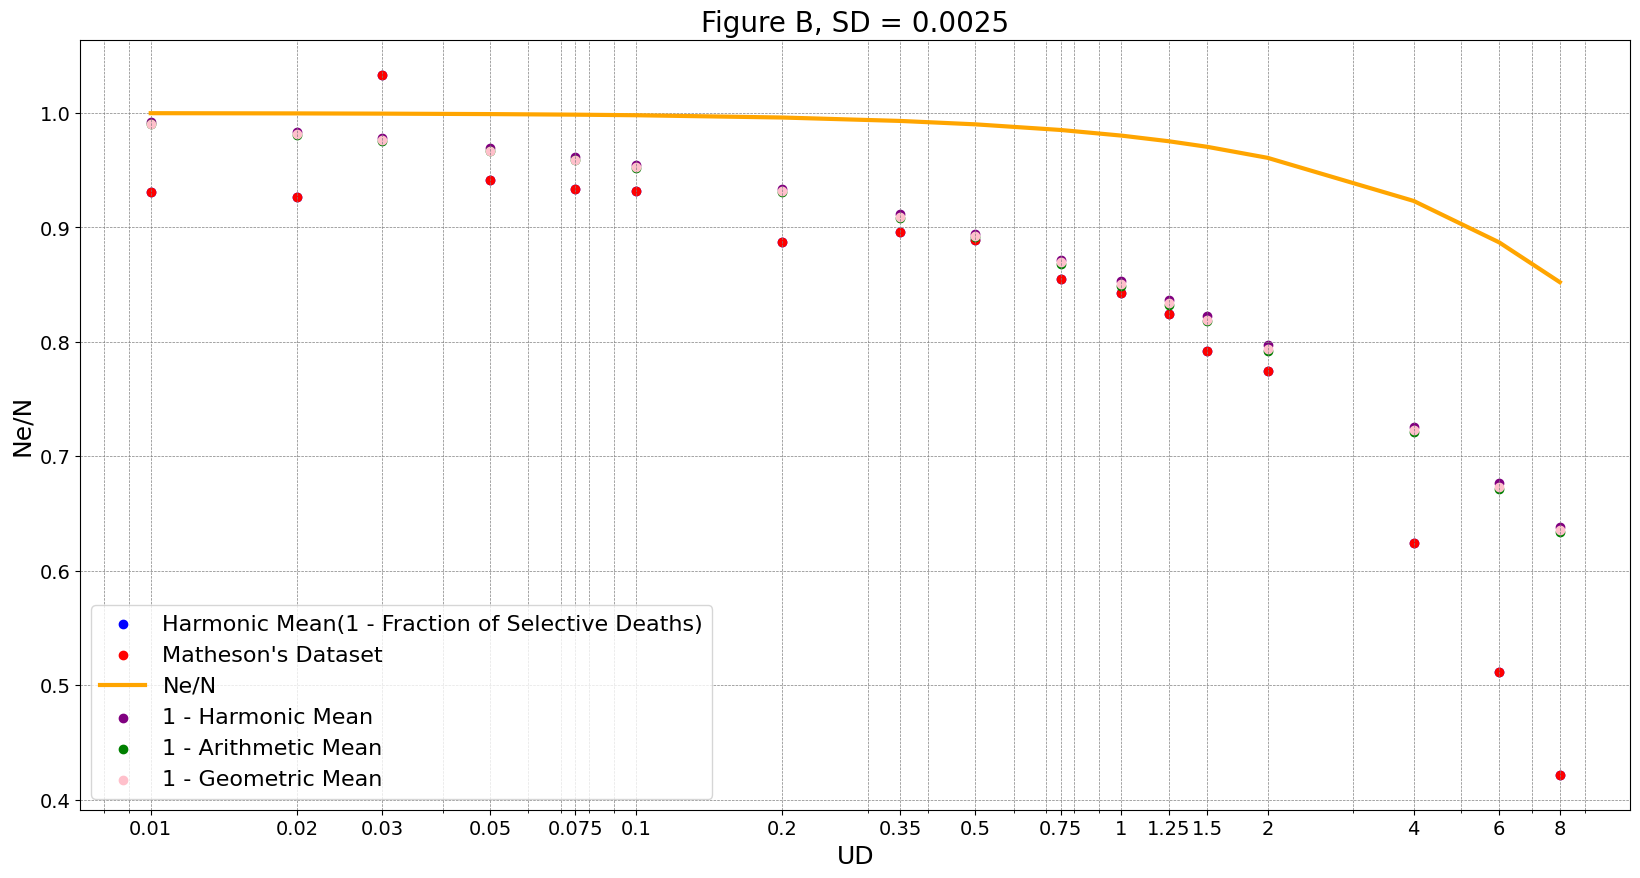

In [22]:
# This cell is dedicated to the comparison graph, for the SD value of 0.0025, 1B

sd = 0.0025

b_data = parse_files("0.002500", sd, "FF")
slice_data(b_data)
fig_b_hmean_subtracted_data, fig_b_subtracted_harmonic_means, fig_b_harmonic_means = calculate_harmonic_means(sd)
figB_subtracted_arithmetic_means = calculate_arithmetic_means(sd)
figB_subtracted_geometric_means =calculate_geometric_means(sd)

plt.figure(figsize=(20, 10))


location = "/Users/cameronliu/Desktop/Research/BGSpaperdataforFigure1B.csv"
figB_matheson_dataset = sort_csv(location, sd)
figB_matheson_dataset = [(float(x), float(y)) for x, y in figB_matheson_dataset]
fig_b_subtracted_harmonic_means.sort()

# getting np.exp(-8*ud*sd) to look better in the key


# Build y-axis values by matching ud in tuples
figB_hmean_subtracted_data = [omega for (ud, omega, sd) in fig_b_hmean_subtracted_data if ud in uds] # The original omega, Hmean(1-data)
figB_matheson_dataset = [omega for (ud, omega) in figB_matheson_dataset if ud in uds] # Matheson's Original (simulation, after finishing, make the genetic tree, then add mutations)
matheson_calculated_data = [] # matheson's calculated omega from the data
for ud in uds: 
    matheson_calculated_data.append(float(np.exp(-8*ud*sd)))
figB_subtracted_hmean = [omega for (ud, omega, sd) in fig_b_subtracted_harmonic_means if ud in uds] # 1-hmean(data)
figB_subtracted_arithmetic_means = [arithmetic for (ud, arithmetic, sd) in figB_subtracted_arithmetic_means if ud in uds] # 1-amean(data)
figB_subtracted_geometric_means = [geometric_mean for (ud, geometric_mean, sd) in figB_subtracted_geometric_means if ud in uds] #1-gmean(data)


plt.scatter(uds, figB_matheson_dataset, color='blue', label='Harmonic Mean(1 - Fraction of Selective Deaths)') 
plt.scatter(uds, figB_matheson_dataset, color='red', label="Matheson's Dataset") # Matheson's Dataset
plt.plot(uds, matheson_calculated_data, color='orange', label="Ne/N") # Matheson's Calculated Data (using the formula)
plt.scatter(uds, figB_subtracted_hmean, color='purple', label="1 - Harmonic Mean") # Our New Omega 
plt.scatter(uds, figB_subtracted_arithmetic_means, color="green", label="1 - Arithmetic Mean") # 1 - Arithmetic Mean
plt.scatter(uds, figB_subtracted_geometric_means, color="pink", label = "1 - Geometric Mean") # 1 - Geometric Mean


# Logarithmic scale on x-axis
plt.legend(fontsize='small')
plt.xscale('log')

# Set custom ticks (still linear labels)
ticks = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
plt.xticks(ticks, labels=[str(t) for t in ticks])

# Labels and aesthetics

plt.xlabel("UD")
plt.ylabel("Ne/N")
plt.legend()
plt.title("Figure B, SD = " + str(sd))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig("/Users/cameronliu/Desktop/Research/other-graphs/" + "figBcomparison_graphs.png", dpi=300, bbox_inches='tight')

plt.show()

# unlinked background selection


In [ ]:
# Cell to calculate the fraction of selective deaths histogram
wanted = (2, 4, 6, 8)
bin_count = 200
for tuple in all_datasets: # in this case, tuple represents (A, B), where A is the UD, and B is the array of Fraction of Selective Deaths
    ud = tuple[0]; dataset = tuple[1]
    plt.figure(figsize=(16, 10))
    plt.title("Histogram of Fraction of Selective Deaths, UD = " + str(ud) + ", " + str(bin_count) + " bins")
    plt.hist(dataset, bins=bin_count, edgecolor='blue')
    #plt.savefig("/Users/cameronliu/Desktop/Research/Selective Death Histograms/" + str(ud) + "_sd_histogram_" + str(bin_count) + "_bins.png", dpi=300, bbox_inches='tight')


In [ ]:
# Cell to calculate the transformations, and their plots

wanted = (2, 4, 6, 8)
fitted_lambdas = []
transformed_datasets = []
b_data = parse_files("0.002500", sd, "FF")
for tuple in b_data: # iterates through all the datasets
    ud = tuple[0]; dataset = tuple[1]
    transformed_data, fitted_lambda = stats.boxcox(dataset) # gets the transformed data, and the lambda that is dedicated to that dataset
    transformed_datasets.append((ud, fitted_lambda, transformed_data))
print(len(transformed_datasets))
bin_count = 200
for tuple in transformed_datasets: # in this case, tuple represents (A, B), where A is the UD, and B is the array of Fraction of Selective Deaths
    ud = tuple[0]; fitted_lambda = tuple[1]; dataset = tuple[2]
    if ud in wanted:
        print(ud)
        plt.figure(figsize=(16, 10))
        plt.title("Transformed Histogram of Fraction of Selective Deaths, UD = " + str(ud) + ", " + "Optimal Lambda: " + str(fitted_lambda))
        plt.hist(dataset, bins=bin_count, edgecolor='blue')
        plt.show()
        #plt.savefig("/Users/cameronliu/Desktop/Research/Selective Death Histograms/" + "transformed_lam_" + str(fitted_lambda) + ".png", dpi=300, bbox_inches='tight')

# arithmetic mean of the transformed data
transformed_arithmetic_means = []
for ud, fitted_lambda, data in transformed_datasets: 
    mean = statistics.mean(data)
    transformed_arithmetic_means.append((ud, float(mean)))